## **Scratchpad**


- Survey is Mostly Qualitative
    - Either categorical / rank scale (1-5)
- So many questions that can be asked / answered
- First thought was correlation between a variety of responses and year / program  / demography
    - Correlation within responses
- Histograms will be your friend

---

## Codebook read-in


- There are probably a few ways to hit this, there may be encoding in an Excel tab
- Could Parse out the text from the PDF
   - Regex but will be messy
    - Gemini / Claude API for one-shot NLP?

After spending some time fiddling with a Regex search,  I think 

### **Scope is Graduate School Leadership**

- I think start by scoping the potential types of questions:

  - Financial
  - Academic by:
    - Program
    - Year
  - Demographic?  Doesn't seem there are strong demographic indicators in this set
    - Response bias / survey bias



## **Primary Analysis**

> This analysis focuses on the use of AI by graduate program. The goal is to understand how AI impacts perception of learning outcomes.

- The primary dimension is Program, with splits by Social Sciencees / 

In [1]:
#  --- Using env_finance see environment.yml for quick pacakge installation

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from IPython.display import display, Markdown


In [2]:
# --- Display helper: consistent styling for inline tables
#
# Wraps a DataFrame in a pandas Styler with a shared look (caption, number
# formatting, muted NaN, light header/row rules). Use as display(show_table(df, ...)).
# `max_cols` guards wide frames (like the full survey) from rendering every
# column -- unlike a bare DataFrame repr, a Styler does not truncate columns.

_TABLE_STYLES = [
    {"selector": "caption",
     "props": [("caption-side", "top"), ("text-align", "left"),
               ("font-size", "1rem"), ("font-weight", "600"),
               ("padding", "0.3rem 0 0.5rem 0"), ("color", "#1a1a2e")]},
    {"selector": "th",
     "props": [("background-color", "#5C7077"), ("text-align", "left"),
               ("font-weight", "600"), ("padding", "0.35rem 0.6rem"),
               ("border-bottom", "2px solid #d4d4dc")]},
    {"selector": "td",
     "props": [("padding", "0.3rem 0.6rem"),
               ("border-bottom", "1px solid #ededf2")]},
]

def show_table(df, title=None, hide_index=False, precision=2, max_cols=None):
    """Return a consistently styled Styler for a DataFrame.

    title      : optional caption above the table
    hide_index : drop the index column (use when the index is just a RangeIndex)
    precision  : float decimal places
    max_cols   : cap columns for wide frames (Styler renders all columns otherwise)
    """
    view, note = df, ""
    if max_cols is not None and view.shape[1] > max_cols:
        view = view.iloc[:, :max_cols]
        note = f"  (first {max_cols} of {df.shape[1]} columns)"
    styler = (
        view.style
            .format(precision=precision, na_rep="—", thousands=",")
            .set_table_styles(_TABLE_STYLES)
    )
    if title is not None:
        styler = styler.set_caption(title + note)
    elif note:
        styler = styler.set_caption(note.strip())
    if hide_index:
        styler = styler.hide(axis="index")
    return styler


from matplotlib.text import Text

def wrap_to_axis(text, ax, fontsize=None, fontweight=None, pad_frac=0.98):
    """Break a title onto new lines when it would exceed the axis width."""
    fig = ax.figure
    fig.canvas.draw()                                  # need real geometry to measure
    renderer = fig.canvas.get_renderer()
    max_px = ax.get_window_extent(renderer).width * pad_frac
    probe = Text(0, 0, "", figure=fig, fontsize=fontsize, fontweight=fontweight)
    def w(s):
        probe.set_text(s); return probe.get_window_extent(renderer).width
    lines, cur = [], ""
    for word in text.split():
        trial = word if not cur else cur + " " + word
        if w(trial) <= max_px or not cur:
            cur = trial
        else:
            lines.append(cur); cur = word
    if cur: lines.append(cur)
    return "\n".join(lines)


In [3]:
# Data read-ins and directory setup

directory = os.getcwd()

raw_survey = pd.read_excel(directory + "/CU Boulder SERU dataset_sample.xlsx")

# === Data Dictionary

data_dictionary = pd.read_csv(directory + "/seru_data_dictionary.csv")

data_dictionary[["prefix","sub_question", "suffix"]] = data_dictionary['survey_column'].str.split("_", n=2, expand=True)
data_dictionary['section_code']  = data_dictionary['sub_question'].str[:4]
data_dictionary['sub_question']  = data_dictionary['sub_question'].str[4:]

## **EDA**
#### The following blocks:

 - Conduct basic EDA _(exploratory data analysis)_ using standard methods:
    - `.head()`  - First 10 entries of the dataset
    - `.describe()` - Summary statistics for each variable (column)
    - `.info()` - Data types / metadata  / general information
    - `.shape()`  - The number of rows and columns as `(Rows x Columns)`

 - Look for common data hiccups like:
    - Missing values
    - Incorrect / broken variable types
    - 

---

In [4]:
# --- Tabular description of the survey dataset

display(Markdown("## First 5 rows of the survey dataset"))
display(show_table(raw_survey.head(), max_cols=12))
display(Markdown("---"))
display(Markdown("## Survey Summary Statistics"))
display(show_table(raw_survey.describe()))
display(Markdown("---"))


## First 5 rows of the survey dataset

,PROGRESS,DURATION,FINISHED,CONSENT,GS0101_GSYPPROGNAME,GS0102_GSYPSPECPROG,GS0103B_GSYPSPECSTRT,GS0104_GSYPTAKECRSE_r23,GS0104_GSYPWORKDISS_r23,GS0104_GSYPDEFDDISS_r23,GS0104_GSYPHAVEINTN_r23,GS0104_GSYPHAVERESD_r23
0,100,"1,668",True,Agree,Program name (Seed file),"Educ Foundations, Pol & Prac",Fourth year,Checked,Not Checked,Not Checked,Not Checked,Not Checked
1,100,"1,677",True,Agree,Program name (Seed file),Physics,Sixth year or above,Not Checked,Checked,Not Checked,Not Checked,Not Checked
2,100,"94,906",True,Agree,Program name (Seed file),Electrical Engineering,First year,Checked,Not Checked,Not Checked,Checked,Not Checked
3,100,"1,334",True,Agree,Program name (Seed file),Astrophysical & Planetary Sci,Third year,Checked,Checked,Not Checked,Not Checked,Checked
4,22,541,False,Agree,Program name (Seed file),Electrical Engineering,Fourth year,Not Checked,Checked,Not Checked,Not Checked,Not Checked


---

## Survey Summary Statistics

,PROGRESS,DURATION,GS1208_GSDMCHLD0TO1_2,GS1208_GSDMCHLD0TO1_3,CIP_CODE1,LEVEL_GRAD,YEAR,CIP_CODE2010
count,"1,387.00","1,387.00",101.00,101.00,"1,387.00","1,387.00","1,206.00","1,207.00"
mean,87.73,"233,743.01",0.11,0.59,"258,498.77",2.53,"2,022.14","257,793.39"
std,28.09,"718,568.51",1.07,1.21,"142,780.81",0.85,2.11,"143,460.78"
min,11.00,39.00,-1.00,-1.00,"30,103.00",1.00,"2,005.00","30,103.00"
25%,100.00,"1,119.00",-1.00,-1.00,"140,401.00",3.00,"2,021.00","140,401.00"
50%,100.00,"1,680.00",0.00,1.00,"230,101.00",3.00,"2,023.00","230,101.00"
75%,100.00,"5,640.00",1.00,2.00,"400,601.00",3.00,"2,024.00","400,601.00"
max,100.00,"4,496,931.00",3.00,3.00,"540,101.00",4.00,"2,025.00","540,101.00"


---

In [5]:
display(show_table(
    pd.DataFrame({
        "Data Type": raw_survey.dtypes.astype(str),
        "Unique Values": raw_survey.nunique(),
        "Sample": [raw_survey[c].dropna().iloc[0] if raw_survey[c].notna().any() else None
                   for c in raw_survey.columns],
    }).rename_axis("Variable").reset_index(),
    title="Column Types", hide_index=True,
))

Variable,Data Type,Unique Values,Sample
PROGRESS,int64,35,100
DURATION,int64,"1,204","1,668"
FINISHED,bool,2,True
CONSENT,str,1,Agree
GS0101_GSYPPROGNAME,str,2,Program name (Seed file)
GS0102_GSYPSPECPROG,str,76,"Educ Foundations, Pol & Prac"
GS0103B_GSYPSPECSTRT,object,7,Fourth year
GS0104_GSYPTAKECRSE_r23,str,2,Checked
GS0104_GSYPWORKDISS_r23,str,2,Not Checked
GS0104_GSYPDEFDDISS_r23,str,2,Not Checked


In [6]:
# --- General Info about the survey dataset

display(Markdown("## Survey Info"))
raw_survey.info() 
display(Markdown("---"))
display(Markdown(f"## Survey Shape: `{raw_survey.shape}`"))
display(Markdown("---"))
#display(Markdown(f"## Survey Variables:"))
#display(Markdown("\n".join(f"- `{c}`" for c in raw_survey.columns)))


## Survey Info

<class 'pandas.DataFrame'>
RangeIndex: 1387 entries, 0 to 1386
Columns: 289 entries, PROGRESS to CIP_CODE2010
dtypes: bool(1), float64(4), int64(4), object(252), str(28)
memory usage: 3.4+ MB


---

## Survey Shape: `(1387, 289)`

---

In [7]:
# --- Looking for potential missing values in the survey dataset

# Using Pandas indexing to identify missing values in the survey dataset
missing_data = pd.DataFrame({
    "Data Type": raw_survey.dtypes,
    "Quantity Missing": raw_survey.isnull().sum(),
})

missing_data = missing_data.rename_axis("Variable").reset_index()
missing_data = missing_data[missing_data["Quantity Missing"] > 0]

display(Markdown("## Missing Values in the Survey Dataset"))
display(show_table(missing_data, hide_index=True))
display(Markdown("---"))

## Missing Values in the Survey Dataset

Variable,Data Type,Quantity Missing
GS1101_GSOSQLTYINST,object,41
GS1101_GSOSCRSEAVLB,object,41
GS1101_GSOSQLTYADVS,object,41
GS1101_GSOSAVLBADVS,object,41
GS1101_GSOSKNWLGAIN,object,41
GS1101_GSOSFNCLSPPT,object,41
GS1101_GSOSQLTYEQPT,object,41
GS1101_GSOSQLTYOFIT,object,41
GS1101_GSOSQLTYPRDV,object,41
GS1101_GSOSQLTYLIBR,object,41


---

In [8]:
# === Basic Cleaning 

# Drop where all values are missing
raw_survey = raw_survey.dropna(how='all')

ai_use_codes = ["GS1301_GSGAIDAY",
                "GS1303_GSGAIPDC",
                "GS1303_GSGAIAUC",
                "GS1303_GSGAIGPT",
                "GS1303_GSGAIGURW",
                "GS1303_GSGAIGR",
                "GS1303_GSGAIEPDR"]

raw_survey = raw_survey[(raw_survey[ai_use_codes].notnull().any(axis=1))]



In [9]:
raw_survey[ai_use_codes].head()

,GS1301_GSGAIDAY,GS1303_GSGAIPDC,GS1303_GSGAIAUC,GS1303_GSGAIGPT,GS1303_GSGAIGURW,GS1303_GSGAIGR,GS1303_GSGAIEPDR
0,Several times per year,Strongly disagree,Agree,NaN,Strongly disagree,Agree,Agree
1,Daily,Strongly disagree,Strongly disagree,NaN,Strongly disagree,Strongly disagree,Agree
2,Several times per year,Agree,Agree,NaN,Agree,Strongly agree,Agree
3,Several times per month,Strongly agree,Strongly agree,NaN,Strongly agree,Strongly agree,Strongly agree
5,Several times per month,Agree,Agree,Agree,Agree,Agree,Agree


In [10]:

# === Master Plotting Style

import matplotlib as mpl
from cycler import cycler

# CU Boulder brand palette: gold (primary), boulder gray, black + two tints
CU_GOLD, CU_GRAY, CU_BLACK = "#CFB87C", "#565A5C", "#000000"
CU_PALETTE = [CU_GOLD, CU_GRAY, CU_BLACK, "#9EA2A2", "#7A6F52"]

mpl.rcParams.update({
    "axes.prop_cycle": cycler(color=CU_PALETTE),  # CU colors everywhere
    "axes.spines.top":   False,                   # drop top border
    "axes.spines.right": False,                   # drop right border
    "axes.grid":       True,                      # grid on...
    "axes.grid.which": "major",                   # ...major ticks only
    "axes.grid.axis":  "y",                       # y-only (see note)
    "axes.axisbelow":  True,                      # grid behind bars, not over them
    "grid.alpha":      0.35,
    "grid.linewidth":  0.8,
    "figure.subplot.hspace": 0.5,                 # vertical space between stacked subplots
    "axes.ymargin":          0.08,                # headroom above tallest bar
})




Text(0.5, 0.98, 'Gen AI questions')

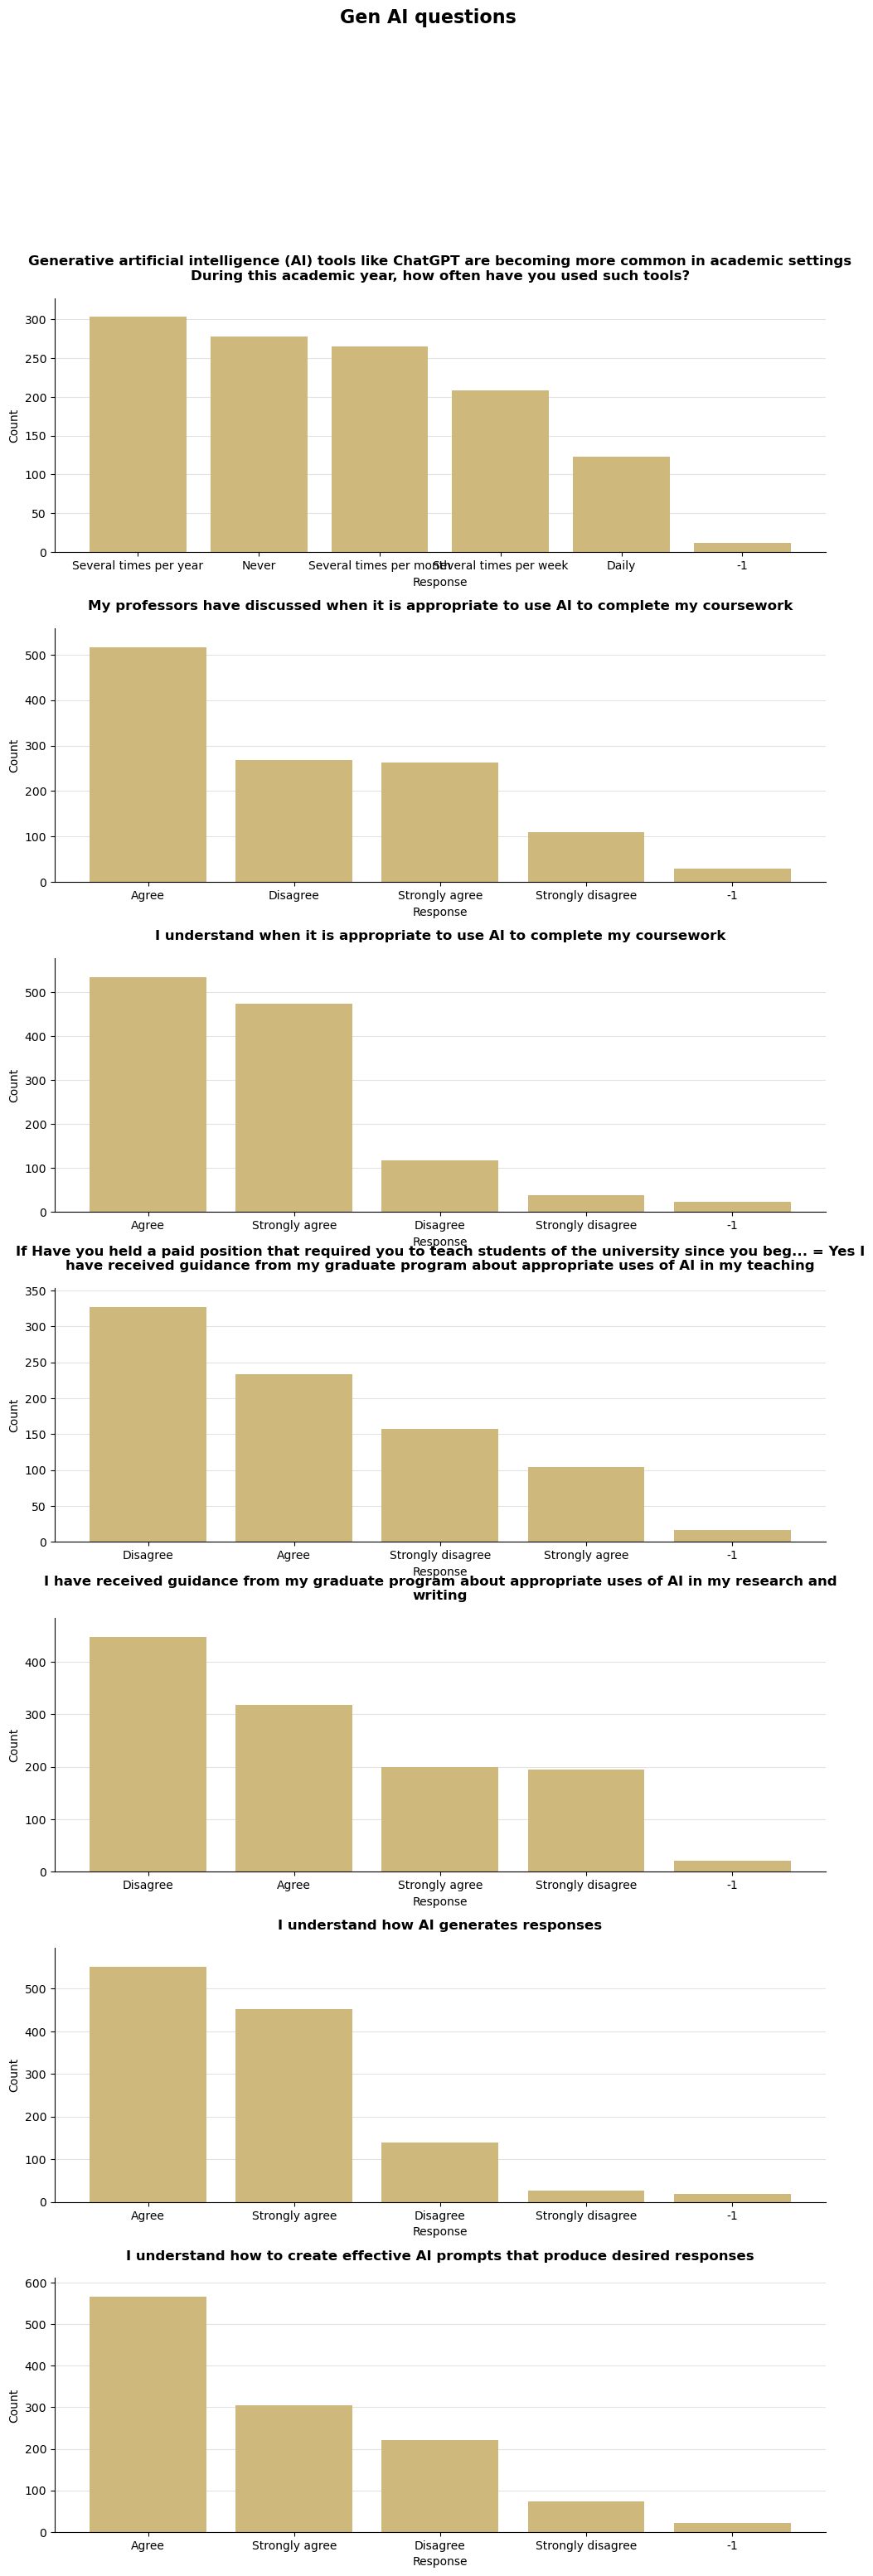

In [ ]:

fig, ax = plt.subplots(len(ai_use_codes), figsize=(12, 5 * len(ai_use_codes)))

ai_use_map = (
    data_dictionary[data_dictionary["survey_column"].isin(ai_use_codes)]
    .set_index("survey_column")[["question_stem", "item_text"]].to_dict(orient="index")
)

for i, code in enumerate(ai_use_codes):
    counts = raw_survey[code].value_counts()
    ax[i].bar(counts.index.astype(str), counts.values)
    
    if i ==0:
        ax[i].set_title(wrap_to_axis(f"{ai_use_map[code]['question_stem']}", ax[i], fontsize=12),fontweight="bold", pad=16)
    else:
        ax[i].set_title(wrap_to_axis(f"{ai_use_map[code]['item_text']}", ax[i], fontsize=12),fontweight="bold", pad=16)
    ax[i].set_xlabel("Response")
    ax[i].set_ylabel("Count")

fig.suptitle("Gen AI questions", fontsize=16, fontweight="bold")